<a href="https://colab.research.google.com/github/ritaqcampos-tech/world-happiness-model/blob/main/world_happiness_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What Makes Nations Happy?
### Economics, Inequality, and a Simpson's Paradox in Global Well-Being
**Author:** Rita Campos

This notebook predicts national life satisfaction for 2005–2024 from economic and social factors, tests the models on countries they never saw, and asks which regions are happier than their economics predict.

**Data**
- World Happiness Report panel data (2005–present): [Kaggle dataset](https://www.kaggle.com/datasets/usamabuttar/world-happiness-report-2005-present). Download the CSV and upload it to Colab before running.
- World Bank Gini index (SI.POV.GINI), pulled automatically from the World Bank API.

**Headline findings**
- Linear regression explains ~68% of happiness differences in unseen countries (R² = 0.68).
- GDP and social support are the strongest predictors.
- Latin America is happier than predicted (+0.40); Southeast Asia is less happy (−0.39).
- Inequality looks positive overall but turns negative within regions (a Simpson's paradox).

## Step 1: Load the data
Loads the World Happiness Report panel (one row per country per year) and checks its size, columns, and missing values.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd, glob

files = glob.glob("/*.csv") + glob.glob("/content/*.csv")
print(files)

raw = pd.read_csv([f for f in files if "WHR2024-selected" not in f][0])
print(raw.shape)
print(raw.columns.tolist())
print(raw.isna().sum())
raw.head()

['/WHR2024-selected-columns.csv', '/World Happiness Report-selected-columns.csv']
(2199, 10)
['Country Name', 'Regional Indicator', 'Year', 'Life Ladder', 'Log GDP Per Capita', 'Social Support', 'Healthy Life Expectancy At Birth', 'Freedom To Make Life Choices', 'Generosity', 'Perceptions Of Corruption']
Country Name                          0
Regional Indicator                  112
Year                                  0
Life Ladder                           0
Log GDP Per Capita                   20
Social Support                       13
Healthy Life Expectancy At Birth     54
Freedom To Make Life Choices         33
Generosity                           73
Perceptions Of Corruption           116
dtype: int64


,Country Name,Regional Indicator,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption
0,Afghanistan,South Asia,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686
1,Afghanistan,South Asia,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035
2,Afghanistan,South Asia,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766
3,Afghanistan,South Asia,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109
4,Afghanistan,South Asia,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620


## Step 2: Baseline model (linear regression)
Cleans the data and trains a simple linear regression to predict happiness.

- Drops rows with missing values (1,964 rows remain).
- Splits by **country**: 80% of countries train the model and 20% test it. This stops the model from "memorizing" a country from other years.
- Reports R² (share of happiness differences explained) and average error on the 0–10 scale.

**Result:** R² = 0.682, average error = 0.45 points.

In [2]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Shorter names
data = raw.rename(columns={
    "Country Name": "country", "Regional Indicator": "region", "Year": "year",
    "Life Ladder": "happiness", "Log GDP Per Capita": "gdp",
    "Social Support": "social", "Healthy Life Expectancy At Birth": "health",
    "Freedom To Make Life Choices": "freedom", "Generosity": "generosity",
    "Perceptions Of Corruption": "corruption"})

features = ["gdp", "social", "health", "freedom", "generosity", "corruption"]

# 2. Drop rows with missing values
data = data.dropna(subset=features + ["happiness"])
print("Rows after cleaning:", len(data))

# 3. Split by country: test countries are never seen during training
X, y = data[features], data["happiness"]
split = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, test_idx = next(split.split(X, y, groups=data["country"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 4. Train and test
model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

print("R²:", round(r2_score(y_test, pred), 3))
print("Avg error:", round(mean_absolute_error(y_test, pred), 3), "points")
print(pd.Series(model.coef_, index=features).round(3))

Rows after cleaning: 1964
R²: 0.682
Avg error: 0.45 points
gdp           0.414
social        2.512
health        0.021
freedom       1.113
generosity    0.749
corruption   -0.650
dtype: float64


## Step 3: Which factors matter most? Linear vs. random forest
- Puts every factor on the same scale (standardized coefficients) so their effects can be compared fairly.
- Trains a random forest, a more flexible model, to see if it predicts better.

**Result:** GDP (0.49) and social support (0.32) matter most. The random forest (R² = 0.661) did slightly *worse* than linear regression, so the relationships are mostly straight-line.

Standardized coefficients:
 corruption   -0.122
generosity    0.114
health        0.145
freedom       0.161
social        0.316
gdp           0.488
dtype: float64

Random Forest R²: 0.661
Random Forest avg error: 0.486


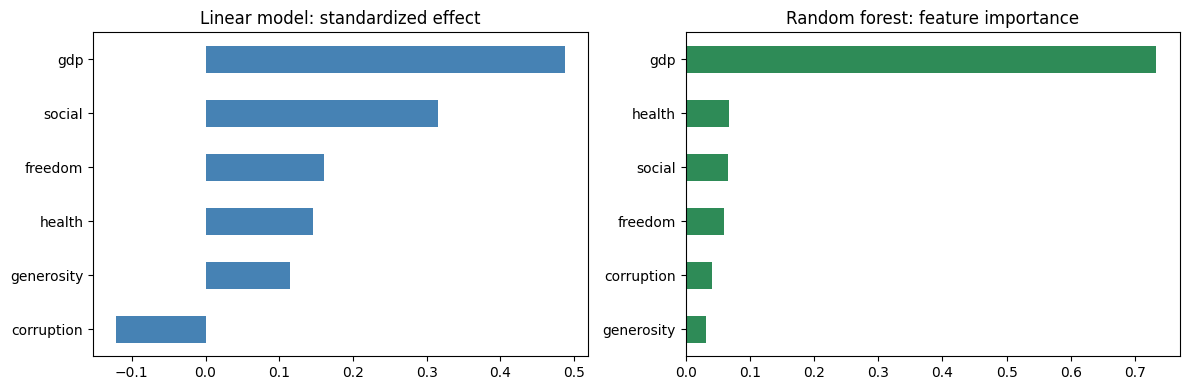

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# A. Standardized coefficients (fair comparison)
scaler = StandardScaler().fit(X_train)
lin = LinearRegression().fit(scaler.transform(X_train), y_train)
std_coefs = pd.Series(lin.coef_, index=features).sort_values()
print("Standardized coefficients:\n", std_coefs.round(3))

# B. Random forest (can capture non-linear patterns)
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("\nRandom Forest R²:", round(r2_score(y_test, rf_pred), 3))
print("Random Forest avg error:", round(mean_absolute_error(y_test, rf_pred), 3))

# C. Side-by-side charts
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
std_coefs.plot.barh(ax=ax[0], color="steelblue")
ax[0].set_title("Linear model: standardized effect")
pd.Series(rf.feature_importances_, index=features).sort_values().plot.barh(
    ax=ax[1], color="seagreen")
ax[1].set_title("Random forest: feature importance")
plt.tight_layout()
plt.show()

## Step 4: Who is happier than predicted?
Predicts every country using models that never saw that country, then calculates the gap: **actual minus predicted happiness**. A positive gap means a country is happier than its economics suggest.

**Result:** Latin America is the biggest overperformer (+0.40). Southeast Asia (−0.39) and East Asia (−0.25) are the biggest underperformers.

Happier than predicted:
 country
Brazil        0.73
Guyana        0.74
Venezuela     0.80
Burundi       0.82
Costa Rica    0.88
Guatemala     0.91
Israel        0.94
Mexico        0.96
Somalia       1.15
Pakistan      1.20
Name: gap, dtype: float64

Less happy than predicted:
 country
Sri Lanka   -1.40
Botswana    -1.39
Rwanda      -1.24
Myanmar     -1.16
Bahrain     -1.00
Bulgaria    -0.97
Tanzania    -0.91
Singapore   -0.81
Cambodia    -0.77
Lebanon     -0.67
Name: gap, dtype: float64


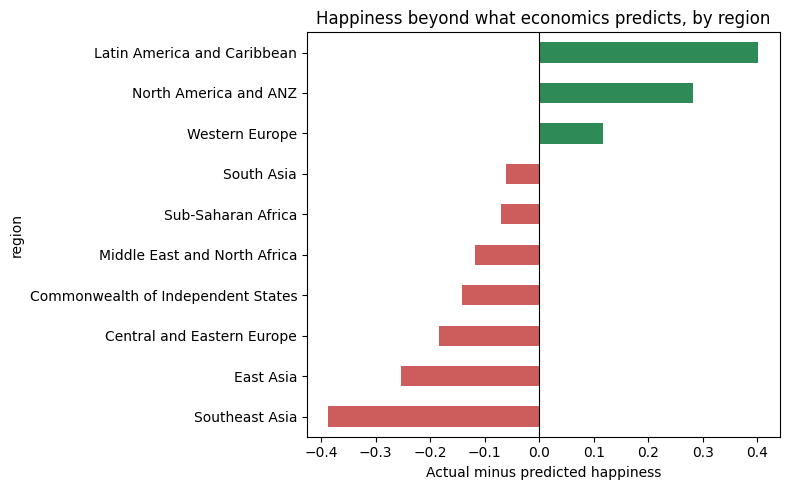

In [4]:
from sklearn.model_selection import GroupKFold, cross_val_predict

# Predict every row using models that never saw that country
data["predicted"] = cross_val_predict(
    LinearRegression(), X, y, groups=data["country"], cv=GroupKFold(n_splits=5))
data["gap"] = data["happiness"] - data["predicted"]

# Average gap per country
by_country = data.groupby("country")["gap"].mean().sort_values()
print("Happier than predicted:\n", by_country.tail(10).round(2))
print("\nLess happy than predicted:\n", by_country.head(10).round(2))

# Average gap per region
by_region = data.groupby("region")["gap"].mean().sort_values()
by_region.plot.barh(color=["indianred" if v < 0 else "seagreen" for v in by_region],
                    figsize=(8, 5))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Happiness beyond what economics predicts, by region")
plt.xlabel("Actual minus predicted happiness")
plt.tight_layout()
plt.show()

Exact regional averages behind the chart above (actual minus predicted happiness).

In [5]:
print(by_region.round(2))

region
Southeast Asia                       -0.39
East Asia                            -0.25
Central and Eastern Europe           -0.18
Commonwealth of Independent States   -0.14
Middle East and North Africa         -0.12
Sub-Saharan Africa                   -0.07
South Asia                           -0.06
Western Europe                        0.12
North America and ANZ                 0.28
Latin America and Caribbean           0.40
Name: gap, dtype: float64


## Step 5: Add income inequality (World Bank Gini)
Pulls the Gini index (0 = perfectly equal, 100 = maximally unequal) from the World Bank and matches it to each country. Countries only measure inequality every few years, so each country's **average since 2000** is used.

**Result:** 1,883 of 1,964 rows (96%) matched.

In [6]:
!pip install -q country_converter
import requests, country_converter as coco

# Pull Gini data from the World Bank
url = ("https://api.worldbank.org/v2/country/all/indicator/SI.POV.GINI"
       "?format=json&per_page=20000&date=2000:2024")
rows = requests.get(url).json()[1]
gini = pd.DataFrame([{"iso3": r["countryiso3code"], "gini": r["value"]} for r in rows])
gini = gini.dropna()
gini = gini[gini["iso3"] != ""]
gini_avg = gini.groupby("iso3")["gini"].mean().rename("gini")
print("Countries with Gini data:", len(gini_avg))

# Match country names to standard codes, then merge
names = data["country"].unique()
iso = dict(zip(names, coco.convert(names=list(names), to="ISO3", not_found=None)))
data["iso3"] = data["country"].map(iso)
data = data.drop(columns="gini", errors="ignore").merge(
    gini_avg, left_on="iso3", right_index=True, how="left")

print("Rows with Gini:", data["gini"].notna().sum(), "of", len(data))
print("Missing Gini:", sorted(data.loc[data["gini"].isna(), "country"].unique()))

Countries with Gini data: 168
Rows with Gini: 1883 of 1964
Missing Gini: ['Afghanistan', 'Bahrain', 'Cambodia', 'Guyana', 'Kuwait', 'Libya', 'New Zealand', 'Saudi Arabia', 'Singapore', 'Somalia', 'Taiwan Province of China', 'Trinidad and Tobago']


## Step 6: Does inequality explain happiness?
Compares model accuracy with and without Gini, measures inequality's effect next to the other factors, and plots inequality against each country's happiness gap.

**Result:** Gini barely improves prediction (R² 0.705 → 0.707), and its effect is slightly **positive** (+0.09). The chart shows why: Latin America is both very unequal and very happy.

R² without Gini: 0.705
R² with Gini:    0.707

Standardized coefficients:
 corruption   -0.150
gini          0.090
generosity    0.104
freedom       0.145
health        0.219
social        0.298
gdp           0.434
dtype: float64

Correlation, inequality vs. gap: 0.121


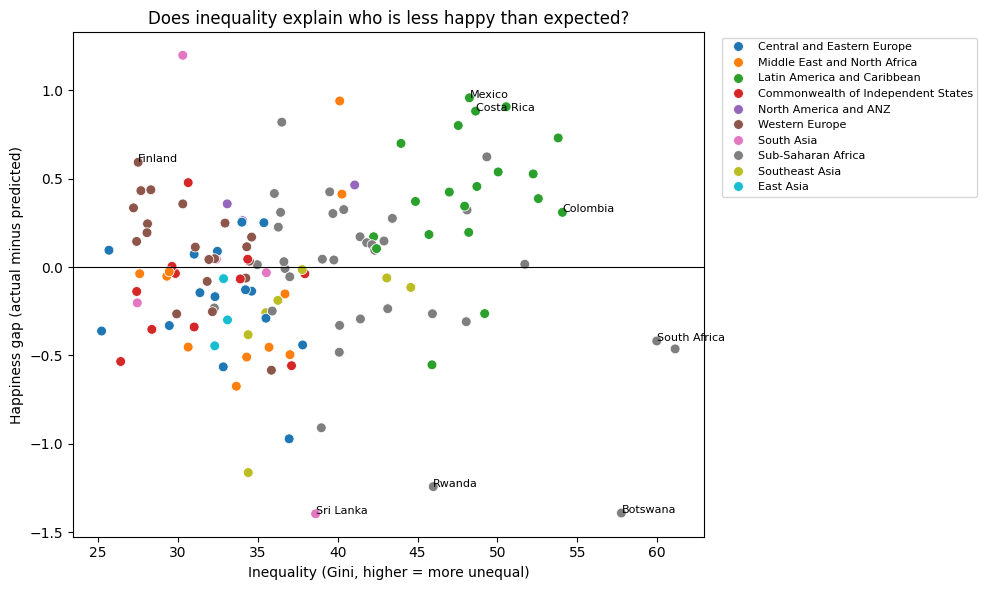

In [7]:
from sklearn.model_selection import cross_val_score

sub = data.dropna(subset=["gini"])
cv = GroupKFold(n_splits=5)

# 1. Does adding Gini improve predictions? (same countries, fair comparison)
base = cross_val_score(LinearRegression(), sub[features], sub["happiness"],
                       groups=sub["country"], cv=cv, scoring="r2").mean()
plus = cross_val_score(LinearRegression(), sub[features + ["gini"]], sub["happiness"],
                       groups=sub["country"], cv=cv, scoring="r2").mean()
print("R² without Gini:", round(base, 3))
print("R² with Gini:   ", round(plus, 3))

# 2. How big is inequality's effect compared to the others?
Xs = StandardScaler().fit_transform(sub[features + ["gini"]])
coefs = pd.Series(LinearRegression().fit(Xs, sub["happiness"]).coef_,
                  index=features + ["gini"])
print("\nStandardized coefficients:\n", coefs.sort_values().round(3))

# 3. Does inequality explain the happiness gaps?
country = sub.groupby("country").agg(gap=("gap", "mean"), gini=("gini", "first"),
                                     region=("region", "first"))
print("\nCorrelation, inequality vs. gap:", round(country["gap"].corr(country["gini"]), 3))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=country, x="gini", y="gap", hue="region", s=50)
for name in ["Botswana", "South Africa", "Sri Lanka", "Rwanda", "Singapore",
             "Costa Rica", "Mexico", "Colombia", "Finland"]:
    if name in country.index:
        plt.annotate(name, (country.loc[name, "gini"], country.loc[name, "gap"]), fontsize=8)
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("Inequality (Gini, higher = more unequal)")
plt.ylabel("Happiness gap (actual minus predicted)")
plt.title("Does inequality explain who is less happy than expected?")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Step 7: Simpson's paradox check
Tests inequality again two ways: with Latin America removed, and with region controls.

**Result:** The effect flips **negative** (−0.11 without Latin America, −0.10 controlling for region). Within the same region, more inequality goes with less happiness. Adding region also raises R² to 0.734.

In [8]:
# 1. Remove Latin America and recheck
no_latam = country[country["region"] != "Latin America and Caribbean"]
print("Correlation without Latin America:",
      round(no_latam["gap"].corr(no_latam["gini"]), 3))

# 2. Control for region directly
reg = pd.get_dummies(sub["region"], drop_first=True, dtype=float)
Xr = pd.concat([sub[features + ["gini"]], reg], axis=1)
m = LinearRegression().fit(StandardScaler().fit_transform(Xr), sub["happiness"])
print("Gini effect, controlling for region:",
      round(pd.Series(m.coef_, index=Xr.columns)["gini"], 3))

r2 = cross_val_score(LinearRegression(), Xr, sub["happiness"],
                     groups=sub["country"], cv=cv, scoring="r2").mean()
print("R² with region added:", round(r2, 3))

Correlation without Latin America: -0.114
Gini effect, controlling for region: -0.104
R² with region added: 0.734


## Limitations
- Correlation, not causation.
- Gini is averaged over 2000–2024 and missing for some countries.
- Happiness is self-reported and may reflect cultural differences in how people answer surveys.